## **TMDB Movie Data Analysis using Spark and APIs**


In [1]:
import os
import time
import json
import sys
import pandas as pd
import requests
from dotenv import load_dotenv
from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt
from pathlib import Path


### *Functions from scripts*

In [2]:
sys.path.append(os.path.abspath("..")) 
from src.tmdb_client import fetch_movie_with_credits
from src.bronze_to_spark import read_bronze_json
import src.silver_transform as st
import src.kpi_movies as km
import src.gold_analysis as ga
from src.download_tmdb_bronze import download_movies_parallel


Let us start the Spark session.

In [3]:
spark = SparkSession.builder.appName("tmdb_lab").getOrCreate()
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/22 11:13:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1. **Fetching the movie data from the API**

In this project, we will follow the medallion workflow to ingest, transform and analyze the movie data for the wanted ids.

In [4]:
load_dotenv()

TMDB_API_KEY = os.getenv("TMDB_API_KEY")

print(f"The TMDB API Key is fetched")

The TMDB API Key is fetched


In [5]:
# TMDB base URLs and Endpoints
BASE_URL = "https://api.themoviedb.org/3"
MOVIE_ENDPOINT = f"{BASE_URL}/movie"
CREDITS_ENDPOINT = f"{BASE_URL}/movie"

# Movie IDs to fetch
movie_ids = [
    0, 299534, 19995, 140607, 299536, 597, 135397, 420818,
    24428, 168259, 99861, 284054, 12445, 181808, 330457,
    351286, 109445, 321612, 260513
]

len(movie_ids), movie_ids[:5]


(19, [0, 299534, 19995, 140607, 299536])

### **Bronze Layer:**

#### **Bronze Ingestion**
Let us ingest our raw data as JSON first

In [6]:
PROJECT_ROOT = Path(os.getcwd()).parent
out_dir = PROJECT_ROOT / "data" / "bronze" / "tmdb_raw_json"
out_dir.mkdir(parents=True, exist_ok=True)


In [7]:
results = download_movies_parallel(
    movie_ids=movie_ids,
    out_dir=out_dir,
    api_key=TMDB_API_KEY,
    max_workers=8,
    sleep_between_calls=0.0  
)

2026-02-22 11:13:29 | INFO | tmdb_pipeline | Starting TMDB download: n_ids=19 max_workers=8 out_dir=/mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/bronze/tmdb_raw_json
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=597 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=299536 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=299534 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=19995 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=140607 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=24428 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=420818 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=99861 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=351286 status=skipped_exists
2026-02-22 11:13:29 | INFO | tmdb_pipeline | movie_id=181808 status=skippe

[HTTP 404] Failed: https://api.themoviedb.org/3/movie/0 | {'success': False, 'status_code': 6, 'status_message': 'Invalid id: The pre-requisite id is invalid or not found.'}
ID 0: Movie not found. Skipping


In [8]:
len(list(out_dir.glob("*.json"))) # Let us see the number of moies fetched

18

#### **Bronze to Spark**
Now we can read the Bronze JSON into Spark

In [9]:
bronze_path = str(out_dir)
bronze_df = read_bronze_json(spark, bronze_path)

2026-02-22 11:13:30 | INFO | tmdb_pipeline | read_bronze_json: reading bronze JSON from /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/bronze/tmdb_raw_json (multiLine=True)
2026-02-22 11:13:33 | INFO | tmdb_pipeline | read_bronze_json: schema columns=['credits', 'fetched_at', 'movie']
2026-02-22 11:13:35 | INFO | tmdb_pipeline | read_bronze_json: successfully loaded bronze data


In [10]:
bronze_df.printSchema()

bronze_df.select("movie.id", "movie.title", "credits.id","fetched_at").show(5, truncate=False)

print("Bronze count:", bronze_df.count())


root
 |-- credits: struct (nullable = true)
 |    |-- cast: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- adult: boolean (nullable = true)
 |    |    |    |-- cast_id: long (nullable = true)
 |    |    |    |-- character: string (nullable = true)
 |    |    |    |-- credit_id: string (nullable = true)
 |    |    |    |-- gender: long (nullable = true)
 |    |    |    |-- id: long (nullable = true)
 |    |    |    |-- known_for_department: string (nullable = true)
 |    |    |    |-- name: string (nullable = true)
 |    |    |    |-- order: long (nullable = true)
 |    |    |    |-- original_name: string (nullable = true)
 |    |    |    |-- popularity: double (nullable = true)
 |    |    |    |-- profile_path: string (nullable = true)
 |    |-- crew: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- adult: boolean (nullable = true)
 |    |    |    |-- credit_id: string (nullable = true)
 |

26/02/22 11:13:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Bronze count: 18


All our movies are now stored into a spark data frame

## 2. **Silver Layer: Data Cleaning and Preprocessing**

Since we have our data in a dataframe now we can go ahead and clean it according to what we need from it
### **Data Preparation and Cleaning**
#### **Cast and Director Information**
Let us make sure we also have the credits information like crew size and all that.


In [11]:
credits_df = (bronze_df.select( F.col("movie.id").alias("id"),
        F.col("credits.cast").alias("cast_arr"),
        F.col("credits.crew").alias("crew_arr"),))

credits_df = st.add_credits_features(credits_df, cast_top_n=30)

# drop arrays after deriving features
credits_df = credits_df.drop("cast_arr", "crew_arr")

credits_df.show(5, truncate=False)
credits_df.printSchema()

+------+-------------+---------+---------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|id    |director     |cast_size|crew_size|cast                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
+-----

#### **Droping irrelevant columns**
Rather than removing unnecessary fields after loading the data, we applied column projection at read time by explicitly selecting only the attributes required for analysis. Columns such as `adult`, `imdb_id`, `original_title`, `video`, and `homepage` were excluded by not selecting them from the nested TMDB JSON structure.


In [12]:
# Keeping only the columns we need (Droping everything else)
base = st.build_silver(bronze_df)
base = base.join(credits_df, on="id", how="left")


2026-02-22 11:13:38 | INFO | tmdb_pipeline | build_silver: selecting and flattening movie fields from bronze
2026-02-22 11:13:38 | INFO | tmdb_pipeline | build_silver: columns=['id', 'title', 'release_date', 'original_language', 'belongs_to_collection_raw', 'genres_raw', 'spoken_languages_raw', 'production_countries_raw', 'production_companies_raw', 'budget', 'revenue', 'runtime', 'vote_count', 'vote_average', 'popularity', 'overview', 'tagline', 'poster_path', 'status']


In [13]:
base.select("id", "title", "director", "cast_size", "crew_size").show(5, truncate=False)

+------+-----------------------+-------------+---------+---------+
|id    |title                  |director     |cast_size|crew_size|
+------+-----------------------+-------------+---------+---------+
|19995 |Avatar                 |James Cameron|67       |991      |
|299536|Avengers: Infinity War |Anthony Russo|69       |734      |
|24428 |The Avengers           |Joss Whedon  |112      |642      |
|99861 |Avengers: Age of Ultron|Joss Whedon  |74       |654      |
|299534|Avengers: Endgame      |Anthony Russo|107      |608      |
+------+-----------------------+-------------+---------+---------+
only showing top 5 rows


#### **Evaluating JSON-like columns**
TMDB returns several attributes as nested JSON objects (structs) or lists of objects (arrays of structs) rather than flat scalar values. We inspected their Spark schema using `printSchema()` to understand their internal structure before transforming them into analysis-friendly columns.

In [14]:
base.select(
    "belongs_to_collection_raw",
    "genres_raw",
    "spoken_languages_raw",
    "production_countries_raw",
    "production_companies_raw"
).printSchema()

root
 |-- belongs_to_collection_raw: struct (nullable = true)
 |    |-- backdrop_path: string (nullable = true)
 |    |-- id: long (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- poster_path: string (nullable = true)
 |-- genres_raw: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- id: long (nullable = true)
 |    |    |-- name: string (nullable = true)
 |-- spoken_languages_raw: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- english_name: string (nullable = true)
 |    |    |-- iso_639_1: string (nullable = true)
 |    |    |-- name: string (nullable = true)
 |-- production_countries_raw: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- iso_3166_1: string (nullable = true)
 |    |    |-- name: string (nullable = true)
 |-- production_companies_raw: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- id: long (nullab

From the schema:

- `belongs_to_collection_raw` is a struct containing fields such as `id` and `name` → we extract `name`.

- `genres_raw`, `production_countries_raw`, and `production_companies_raw` are arrays of structs where the main descriptive field is `name`.

- `spoken_languages_raw` is an array of structs that includes both `name` and `english_name` → we typically use `english_name` for consistent readability.

This schema inspection step ensures we extract the correct fields and avoid null/incorrect transformations when flattening the data into Silver format.


#### **Extraction of key Data Points**
Now that we understand the stracture, we can go ahead and extract the data we actually need from the JSON.

**Collection Name**

In [15]:
silver_df = st.add_collection(base)

In [16]:
silver_df.select("id", "title", "belongs_to_collection").show(5, truncate=False)

st.value_counts(silver_df, "belongs_to_collection").show(truncate=False)


+------+-----------------------+-----------------------+
|id    |title                  |belongs_to_collection  |
+------+-----------------------+-----------------------+
|19995 |Avatar                 |Avatar Collection      |
|299536|Avengers: Infinity War |The Avengers Collection|
|24428 |The Avengers           |The Avengers Collection|
|99861 |Avengers: Age of Ultron|The Avengers Collection|
|299534|Avengers: Endgame      |The Avengers Collection|
+------+-----------------------+-----------------------+
only showing top 5 rows
+-----------------------------------+-----+
|belongs_to_collection              |count|
+-----------------------------------+-----+
|The Avengers Collection            |4    |
|Jurassic Park Collection           |2    |
|Star Wars Collection               |2    |
|Frozen Collection                  |2    |
|NULL                               |2    |
|Avatar Collection                  |1    |
|Black Panther Collection           |1    |
|The Incredibles Collec

**Genres**

In [17]:
silver_df = st.add_genres(silver_df)

silver_df.select("id", "title", "genres").show(5, truncate=False)

+------+-----------------------+----------------------------------------+
|id    |title                  |genres                                  |
+------+-----------------------+----------------------------------------+
|19995 |Avatar                 |Action|Adventure|Fantasy|Science Fiction|
|299536|Avengers: Infinity War |Adventure|Action|Science Fiction        |
|24428 |The Avengers           |Science Fiction|Action|Adventure        |
|99861 |Avengers: Age of Ultron|Action|Adventure|Science Fiction        |
|299534|Avengers: Endgame      |Adventure|Science Fiction|Action        |
+------+-----------------------+----------------------------------------+
only showing top 5 rows


In [18]:
silver_df.select( F.explode(F.split(F.col("genres"), "\\|")).alias("genre")).groupBy("genre").count().orderBy(F.desc("count")).show(10)

+---------------+-----+
|          genre|count|
+---------------+-----+
|      Adventure|   15|
|         Action|   12|
|Science Fiction|   10|
|        Fantasy|    5|
|         Family|    5|
|      Animation|    4|
|       Thriller|    3|
|        Romance|    2|
|          Drama|    2|
|          Crime|    1|
+---------------+-----+
only showing top 10 rows


In [19]:
# Value counts to check if all rows are accounted for
st.value_counts(silver_df, "genres").show(truncate=False)


+-----------------------------------------+-----+
|genres                                   |count|
+-----------------------------------------+-----+
|Adventure|Action|Science Fiction         |3    |
|Action|Adventure|Science Fiction         |2    |
|Action|Adventure|Science Fiction|Thriller|2    |
|Action|Adventure|Fantasy|Science Fiction |1    |
|Science Fiction|Action|Adventure         |1    |
|Adventure|Science Fiction|Action         |1    |
|Drama|Romance                            |1    |
|Animation|Family|Adventure|Fantasy       |1    |
|Action|Adventure|Animation|Family        |1    |
|Action|Crime|Thriller                    |1    |
|Family|Fantasy|Romance                   |1    |
|Adventure|Fantasy                        |1    |
|Adventure|Drama|Family|Animation         |1    |
|Family|Animation|Adventure|Comedy|Fantasy|1    |
+-----------------------------------------+-----+



**Spoken Languages**

In [20]:
silver_df = st.add_spoken_languages(silver_df)

silver_df.select("id", "title", "spoken_languages").show(5, truncate=False)

+------+-----------------------+----------------------+
|id    |title                  |spoken_languages      |
+------+-----------------------+----------------------+
|19995 |Avatar                 |English|Spanish       |
|299536|Avengers: Infinity War |English|Xhosa         |
|24428 |The Avengers           |English|Hindi|Russian |
|99861 |Avengers: Age of Ultron|English               |
|299534|Avengers: Endgame      |English|Japanese|Xhosa|
+------+-----------------------+----------------------+
only showing top 5 rows


In [21]:
silver_df.select(F.explode(F.split(F.col("spoken_languages"), "\\|")).alias("language")
).groupBy("language").count().orderBy(F.desc("count")).show()

+--------+-----+
|language|count|
+--------+-----+
| English|   18|
| Russian|    3|
|   Xhosa|    3|
| Spanish|    2|
|  French|    2|
|   Hindi|    1|
|Japanese|    1|
|  Korean|    1|
| Swahili|    1|
| Italian|    1|
|  German|    1|
| Swedish|    1|
|    Thai|    1|
|  Arabic|    1|
+--------+-----+



In [22]:
# Value Counts
st.value_counts(silver_df, "spoken_languages").show(truncate=False)


+---------------------------------------------+-----+
|spoken_languages                             |count|
+---------------------------------------------+-----+
|English                                      |9    |
|English|Spanish                              |1    |
|English|Xhosa                                |1    |
|English|Hindi|Russian                        |1    |
|English|Japanese|Xhosa                       |1    |
|English|Korean|Swahili|Xhosa                 |1    |
|English|Russian                              |1    |
|English|French|German|Swedish|Italian|Russian|1    |
|Arabic|English|Spanish|Thai                  |1    |
|English|French                               |1    |
+---------------------------------------------+-----+



**Production Countries**

In [23]:
silver_df = st.add_production_countries(silver_df)

silver_df.select("id", "title", "production_countries").show(5, truncate=False)



+------+-----------------------+---------------------------------------+
|id    |title                  |production_countries                   |
+------+-----------------------+---------------------------------------+
|19995 |Avatar                 |United States of America|United Kingdom|
|299536|Avengers: Infinity War |United States of America               |
|24428 |The Avengers           |United States of America               |
|99861 |Avengers: Age of Ultron|United States of America               |
|299534|Avengers: Endgame      |United States of America               |
+------+-----------------------+---------------------------------------+
only showing top 5 rows


In [24]:
silver_df.select(F.explode(F.split(F.col("production_countries"), "\\|")).alias("country")
).groupBy("country").count().orderBy(F.desc("count")).show()

+--------------------+-----+
|             country|count|
+--------------------+-----+
|United States of ...|   18|
|      United Kingdom|    2|
+--------------------+-----+



In [25]:
# Value Counts
st.value_counts(silver_df, "production_countries").show(truncate=False)

+---------------------------------------+-----+
|production_countries                   |count|
+---------------------------------------+-----+
|United States of America               |16   |
|United States of America|United Kingdom|1    |
|United Kingdom|United States of America|1    |
+---------------------------------------+-----+



**Production Companies**

In [26]:
silver_df = st.add_production_companies(silver_df)

silver_df.select("id", "title", "production_companies").show(5, truncate=False)


+------+-----------------------+------------------------------------------------------------------------------------+
|id    |title                  |production_companies                                                                |
+------+-----------------------+------------------------------------------------------------------------------------+
|19995 |Avatar                 |Dune Entertainment|Lightstorm Entertainment|20th Century Fox|Ingenious Film Partners|
|299536|Avengers: Infinity War |Marvel Studios                                                                      |
|24428 |The Avengers           |Marvel Studios                                                                      |
|99861 |Avengers: Age of Ultron|Marvel Studios                                                                      |
|299534|Avengers: Endgame      |Marvel Studios                                                                      |
+------+-----------------------+------------------------

In [27]:
silver_df.select(F.explode(F.split(F.col("production_companies"), "\\|")).alias("company")
).groupBy("company").count().orderBy(F.desc("count")).show(10)

+--------------------+-----+
|             company|count|
+--------------------+-----+
|      Marvel Studios|    5|
|  Universal Pictures|    3|
|Lightstorm Entert...|    2|
|    20th Century Fox|    2|
|      Lucasfilm Ltd.|    2|
|Amblin Entertainment|    2|
|Walt Disney Anima...|    2|
|Walt Disney Pictures|    2|
|  Dune Entertainment|    1|
|Ingenious Film Pa...|    1|
+--------------------+-----+
only showing top 10 rows


In [28]:
# Value Counts
st.value_counts(silver_df, "production_companies").show(truncate=False)

+------------------------------------------------------------------------------------+-----+
|production_companies                                                                |count|
+------------------------------------------------------------------------------------+-----+
|Marvel Studios                                                                      |5    |
|Walt Disney Animation Studios                                                       |2    |
|Dune Entertainment|Lightstorm Entertainment|20th Century Fox|Ingenious Film Partners|1    |
|Amblin Entertainment|Universal Pictures|Legendary Pictures                          |1    |
|Amblin Entertainment|Universal Pictures                                             |1    |
|Lucasfilm Ltd.|Bad Robot                                                            |1    |
|Pixar                                                                               |1    |
|Paramount Pictures|20th Century Fox|Lightstorm Entertainment         

For all the transformed columns, the rows match our original extracted rows. The only column spotted to have Null values is movie collection; `belongs_to_collection`. Now we can go ahead and drop the raw JSON columns.

In [29]:
silver_df = silver_df.drop( "belongs_to_collection_raw", "genres_raw",
    "spoken_languages_raw", "production_countries_raw", "production_companies_raw")

silver_df.printSchema()

root
 |-- id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- original_language: string (nullable = true)
 |-- budget: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- runtime: double (nullable = true)
 |-- vote_count: long (nullable = true)
 |-- vote_average: double (nullable = true)
 |-- popularity: double (nullable = true)
 |-- overview: string (nullable = true)
 |-- tagline: string (nullable = true)
 |-- poster_path: string (nullable = true)
 |-- status: string (nullable = true)
 |-- director: string (nullable = true)
 |-- cast_size: integer (nullable = true)
 |-- crew_size: integer (nullable = true)
 |-- cast: string (nullable = true)
 |-- belongs_to_collection: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- spoken_languages: string (nullable = true)
 |-- production_countries: string (nullable = true)
 |-- production_companies: string (nullable = true)



### **Handling Missing & Incorrect Data**

#### **Convert Column Data Types**

Now since we have our columns, we can look at their data types above. All the columns be it numeric, date, or any other columns honestly seem to have their respectful data types.

In [30]:
# A caution for when the data types don't match what we want
silver_df = st.cast_movie_types(silver_df)

silver_df.printSchema()

root
 |-- id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- original_language: string (nullable = true)
 |-- budget: double (nullable = true)
 |-- revenue: double (nullable = true)
 |-- runtime: double (nullable = true)
 |-- vote_count: long (nullable = true)
 |-- vote_average: double (nullable = true)
 |-- popularity: double (nullable = true)
 |-- overview: string (nullable = true)
 |-- tagline: string (nullable = true)
 |-- poster_path: string (nullable = true)
 |-- status: string (nullable = true)
 |-- director: string (nullable = true)
 |-- cast_size: integer (nullable = true)
 |-- crew_size: integer (nullable = true)
 |-- cast: string (nullable = true)
 |-- belongs_to_collection: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- spoken_languages: string (nullable = true)
 |-- production_countries: string (nullable = true)
 |-- production_companies: string (nullable = true)



All numeric and temporal fields are explicitly cast to analysis-safe Spark types. This ensures consistency across transformations and prevents downstream schema drift.

#### **Replacing Unrealistic Values**

Let us now address unrealistic and misleading values in the dataset.
Zero values in numeric fields (e.g., budget, revenue, runtime) are treated as missing, placeholder text is replaced with nulls, vote-related inconsistencies are corrected, and monetary values are normalized to million USD for consistency.

**Zero Values**

We set zero values for some columns to null for ease and accuracy of analysis.


In [31]:
silver_df = st.zero_to_null_cols(silver_df, ["budget", "revenue", "runtime"])

In [32]:
silver_df.select("title", "budget", "revenue", "runtime").show(5, truncate=False)


+-----------------------+------+-------------+-------+
|title                  |budget|revenue      |runtime|
+-----------------------+------+-------------+-------+
|Avatar                 |2.37E8|2.923706026E9|162.0  |
|Avengers: Infinity War |3.0E8 |2.052415039E9|149.0  |
|The Avengers           |2.2E8 |1.518815515E9|143.0  |
|Avengers: Age of Ultron|2.35E8|1.405403694E9|141.0  |
|Avengers: Endgame      |3.56E8|2.7994391E9  |181.0  |
+-----------------------+------+-------------+-------+
only showing top 5 rows


**Millions conversion**

We convert the `budget` and `revenue` columns to millions

In [33]:
silver_df = st.add_musd_columns(silver_df)

**Vote Count**

For movies with no votes, i.e. `vote_count = 0`, their `vote_average` is undefined. We set it to null for transparency.

In [34]:
silver_df = st.nullify_vote_average_when_no_votes(silver_df)


**Overview and Tagline**

Now, let us replace place holders like `No Data` to `NaN`

In [35]:
silver_df = st.nullify_text_placeholders(silver_df, ["overview", "tagline"])


In [36]:
silver_df.select("title","budget","revenue","runtime","budget_musd","revenue_musd").show(10, truncate=False)

+------------------------------+------+-------------+-------+-----------+------------+
|title                         |budget|revenue      |runtime|budget_musd|revenue_musd|
+------------------------------+------+-------------+-------+-----------+------------+
|Avatar                        |2.37E8|2.923706026E9|162.0  |237.0      |2923.706026 |
|Avengers: Infinity War        |3.0E8 |2.052415039E9|149.0  |300.0      |2052.415039 |
|The Avengers                  |2.2E8 |1.518815515E9|143.0  |220.0      |1518.815515 |
|Avengers: Age of Ultron       |2.35E8|1.405403694E9|141.0  |235.0      |1405.403694 |
|Avengers: Endgame             |3.56E8|2.7994391E9  |181.0  |356.0      |2799.4391   |
|Black Panther                 |2.0E8 |1.349926083E9|135.0  |200.0      |1349.926083 |
|Jurassic World                |1.5E8 |1.671537444E9|124.0  |150.0      |1671.537444 |
|Star Wars: The Force Awakens  |2.45E8|2.068223624E9|136.0  |245.0      |2068.223624 |
|Jurassic World: Fallen Kingdom|1.7E8 |1.31

Now that the transformations are successful, we can drop the columns we no longer need: `budget`, `revenue`

In [37]:
silver_df.drop("budget", "revenue")

DataFrame[id: bigint, title: string, release_date: date, original_language: string, runtime: double, vote_count: bigint, vote_average: double, popularity: double, overview: string, tagline: string, poster_path: string, status: string, director: string, cast_size: int, crew_size: int, cast: string, belongs_to_collection: string, genres: string, spoken_languages: string, production_countries: string, production_companies: string, budget_musd: double, revenue_musd: double]

In [38]:
null_counts = (silver_df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in silver_df.columns]))

null_counts.show(truncate=False)

+---+-----+------------+-----------------+------+-------+-------+----------+------------+----------+--------+-------+-----------+------+--------+---------+---------+----+---------------------+------+----------------+--------------------+--------------------+-----------+------------+
|id |title|release_date|original_language|budget|revenue|runtime|vote_count|vote_average|popularity|overview|tagline|poster_path|status|director|cast_size|crew_size|cast|belongs_to_collection|genres|spoken_languages|production_countries|production_companies|budget_musd|revenue_musd|
+---+-----+------------+-----------------+------+-------+-------+----------+------------+----------+--------+-------+-----------+------+--------+---------+---------+----+---------------------+------+----------------+--------------------+--------------------+-----------+------------+
|0  |0    |0           |0                |0     |0      |0      |0         |0           |0         |0       |0      |0          |0     |0       |0  

#### **Missing IDs/Titles**

A way to handle missing ids, and titles for different movies; is to drop the rows where that happens

In [39]:
silver_df = st.drop_bad_ids_titles(silver_df)

#### **Removing Duplicates & Getting Rid of Movies with Not Enough Details**

We want to make sure there are no duplicates in `id`, and get rid of rows with more than 10 columns of missing data.

In [40]:
silver_df = st.dedupe_by_id(silver_df)

# keep rows with >= 10 non-null columns
silver_df =st.keep_min_non_null(silver_df, min_cols=10)

#### **Released Movies**

Checking the status of movies and just keeping the released ones and then dropping the `status` column

In [41]:
silver_df = st.filter_released_drop_status(silver_df)

In [42]:
print("Count:", silver_df.count())
print("Distinct ids:", silver_df.select("id").distinct().count())

Count: 18
Distinct ids: 18


#### **Re-Ordering Columns**


In [43]:
silver_df = st.reorder_silver_columns(silver_df)
silver_df.printSchema()
silver_df.show(5, truncate=False)

2026-02-22 11:13:55 | INFO | tmdb_pipeline | reorder_silver_columns: reordering and selecting final silver columns


root
 |-- id: long (nullable = true)
 |-- title: string (nullable = true)
 |-- tagline: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- genres: string (nullable = true)
 |-- belongs_to_collection: string (nullable = true)
 |-- original_language: string (nullable = true)
 |-- budget_musd: double (nullable = true)
 |-- revenue_musd: double (nullable = true)
 |-- production_companies: string (nullable = true)
 |-- production_countries: string (nullable = true)
 |-- vote_count: long (nullable = true)
 |-- vote_average: double (nullable = true)
 |-- popularity: double (nullable = true)
 |-- runtime: double (nullable = true)
 |-- overview: string (nullable = true)
 |-- spoken_languages: string (nullable = true)
 |-- poster_path: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- cast_size: integer (nullable = true)
 |-- director: string (nullable = true)
 |-- crew_size: integer (nullable = true)

+-----+--------------------------------------------+-----

## 3. **Gold Layer**
### **KPI IMPLEMENTATION & MOVIE PERFORMANCE ANALYSIS**
Now that our data is ready, in this section, we compute key performance indicators (KPIs) related to movie financial performance, popularity, and audience reception. These are to allow us to identify the best and worst performing movies across multiple dimensions and rank them.
 

In [44]:
#  Saving the kpi tables
KPI_DIR = PROJECT_ROOT / "data" / "gold" / "kpis"
KPI_DIR.mkdir(parents=True, exist_ok=True)


### **Profit & Return on Investment (ROI)**

Let us first calculate the Profit and ROI

In [45]:
kpi_df = km.add_kpi_columns(silver_df)

2026-02-22 11:13:56 | INFO | tmdb_pipeline | add_kpi_columns: adding profit_musd and roi


In [46]:

kpi_df.show(5, truncate=False)

+-----+--------------------------------------------+-----------------------------------------+------------+----------------------------------------+-----------------------+-----------------+-----------+------------+------------------------------------------------------------------------------------+---------------------------------------+----------+------------+----------+-------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------+--------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------

### **Best and worst Movies**
Now let us rank movies according to different attributes

#### **wrt Revenue**

In [47]:
top_revenue_df = km.rank_movies(kpi_df, metric_col="revenue_musd", n=20, ascending=False,
    select_cols=["title","revenue_musd","budget_musd","profit_musd"]
)
top_revenue_df.show(truncate=False)

2026-02-22 11:13:57 | INFO | tmdb_pipeline | rank_movies: metric=revenue_musd n=20 ascending=False filters=False


+--------------------------------------------+------------+-----------+------------------+
|title                                       |revenue_musd|budget_musd|profit_musd       |
+--------------------------------------------+------------+-----------+------------------+
|Avatar                                      |2923.706026 |237.0      |2686.706026       |
|Avengers: Endgame                           |2799.4391   |356.0      |2443.4391         |
|Titanic                                     |2264.162353 |200.0      |2064.162353       |
|Star Wars: The Force Awakens                |2068.223624 |245.0      |1823.2236240000002|
|Avengers: Infinity War                      |2052.415039 |300.0      |1752.415039       |
|Jurassic World                              |1671.537444 |150.0      |1521.537444       |
|The Lion King                               |1662.020819 |260.0      |1402.020819       |
|The Avengers                                |1518.815515 |220.0      |1298.815515       |

- The highest revenue generating movie is: Avatar it generated $2923.71M in revenue.
- The lowest revenue generating movie is: Incredibles 2 it generated $1243.23M in revenue.


In [48]:
km.write_kpi_csv(top_revenue_df, str(KPI_DIR / "top_revenue"), single_file=True)

2026-02-22 11:13:57 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/top_revenue (single_file=True)



#### **wrt Budget**

In [49]:
top_budget_df = km.rank_movies( kpi_df, metric_col="budget_musd", n=20, ascending=False,
    select_cols=["title","budget_musd","revenue_musd","profit_musd"])

top_budget_df.show(truncate=False)


2026-02-22 11:13:59 | INFO | tmdb_pipeline | rank_movies: metric=budget_musd n=20 ascending=False filters=False


+--------------------------------------------+-----------+------------+------------------+
|title                                       |budget_musd|revenue_musd|profit_musd       |
+--------------------------------------------+-----------+------------+------------------+
|Avengers: Endgame                           |356.0      |2799.4391   |2443.4391         |
|Star Wars: The Last Jedi                    |300.0      |1332.69883  |1032.69883        |
|Avengers: Infinity War                      |300.0      |2052.415039 |1752.415039       |
|The Lion King                               |260.0      |1662.020819 |1402.020819       |
|Star Wars: The Force Awakens                |245.0      |2068.223624 |1823.2236240000002|
|Avatar                                      |237.0      |2923.706026 |2686.706026       |
|Avengers: Age of Ultron                     |235.0      |1405.403694 |1170.403694       |
|The Avengers                                |220.0      |1518.815515 |1298.815515       |

- The highest budgeted movie is: Avengers: Endgame        with $356.0M budget
- The lowest budgeted movie is: Harry Potter and the Deathly Hallows: Part 2 with $125.0M Budget


In [50]:
km.write_kpi_csv(top_budget_df, str(KPI_DIR / "top_budget"), single_file=True)

2026-02-22 11:14:00 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/top_budget (single_file=True)



#### **wrt Profit**

In [51]:
# Highest
top_profit_df = km.rank_movies(kpi_df, metric_col="profit_musd", n=3,ascending=False,
    select_cols=["title","profit_musd","revenue_musd","budget_musd"])

top_profit_df.show(truncate=False)


2026-02-22 11:14:01 | INFO | tmdb_pipeline | rank_movies: metric=profit_musd n=3 ascending=False filters=False


+-----------------+-----------+------------+-----------+
|title            |profit_musd|revenue_musd|budget_musd|
+-----------------+-----------+------------+-----------+
|Avatar           |2686.706026|2923.706026 |237.0      |
|Avengers: Endgame|2443.4391  |2799.4391   |356.0      |
|Titanic          |2064.162353|2264.162353 |200.0      |
+-----------------+-----------+------------+-----------+



In [52]:
km.write_kpi_csv(top_profit_df, str(KPI_DIR / "top_profit"), single_file=True)

2026-02-22 11:14:02 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/top_profit (single_file=True)


In [53]:
# Lowest
low_profit_movie = km.rank_movies(kpi_df, metric_col="profit_musd", n=1,ascending=True,
    select_cols=["title","profit_musd","revenue_musd","budget_musd"])

low_profit_movie.show(truncate=False)


2026-02-22 11:14:03 | INFO | tmdb_pipeline | rank_movies: metric=profit_musd n=1 ascending=True filters=False


+------------------------+-----------+------------+-----------+
|title                   |profit_musd|revenue_musd|budget_musd|
+------------------------+-----------+------------+-----------+
|Star Wars: The Last Jedi|1032.69883 |1332.69883  |300.0      |
+------------------------+-----------+------------+-----------+



In [54]:
km.write_kpi_csv(low_profit_movie, str(KPI_DIR / "low_profit"), single_file=True)

2026-02-22 11:14:04 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/low_profit (single_file=True)


- The highest profit generating movie is: Avatar it generated $2686.71M in profit.
- The lowest profit generating movie is: Star Wars: The Last Jedi it generated $1032.70M in profit.

#### **wrt ROI**

In [55]:
# Highest
top_roi_df = km.rank_movies(kpi_df, metric_col="roi", n=3, ascending=False, filters=[F.col("budget_musd") >= 10],
    select_cols=["title","roi","revenue_musd","budget_musd","profit_musd"])
top_roi_df.show(truncate=False)


2026-02-22 11:14:05 | INFO | tmdb_pipeline | rank_movies: metric=roi n=3 ascending=False filters=True


+--------------+-----------------+------------+-----------+-----------+
|title         |roi              |revenue_musd|budget_musd|profit_musd|
+--------------+-----------------+------------+-----------+-----------+
|Avatar        |12.33631234599156|2923.706026 |237.0      |2686.706026|
|Titanic       |11.320811765     |2264.162353 |200.0      |2064.162353|
|Jurassic World|11.14358296      |1671.537444 |150.0      |1521.537444|
+--------------+-----------------+------------+-----------+-----------+



In [56]:
km.write_kpi_csv(top_roi_df, str(KPI_DIR / "top_roi"), single_file=True)

2026-02-22 11:14:06 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/top_roi (single_file=True)


In [57]:
# Lowest
low_roi_movie = km.rank_movies(kpi_df, metric_col="roi", n=1, ascending=True, filters=[F.col("budget_musd") >= 10],
    select_cols=["title","roi","revenue_musd","budget_musd","profit_musd"])

low_roi_movie.show(truncate=False)

2026-02-22 11:14:07 | INFO | tmdb_pipeline | rank_movies: metric=roi n=1 ascending=True filters=True


+------------------------+-----------------+------------+-----------+-----------+
|title                   |roi              |revenue_musd|budget_musd|profit_musd|
+------------------------+-----------------+------------+-----------+-----------+
|Star Wars: The Last Jedi|4.442329433333334|1332.69883  |300.0      |1032.69883 |
+------------------------+-----------------+------------+-----------+-----------+



In [58]:
km.write_kpi_csv(low_roi_movie, str(KPI_DIR / "low_roi"), single_file=True)

2026-02-22 11:14:08 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/low_roi (single_file=True)


- The highest roi generating movie is: Avatar with 12.34 ROI.
- The lowest roi generating movie is: Star Wars: The Last Jedi with 4.44 ROI.

#### **wrt Votes**
Let us see The top movies with the highest number of votes. these represent titles that received the most audience engagement on TMDB.

In [59]:
top_voted_df = km.rank_movies( kpi_df, metric_col="vote_count", n=5, ascending=False,
    select_cols=["title","vote_count","vote_average"])
top_voted_df.show(truncate=False)


2026-02-22 11:14:09 | INFO | tmdb_pipeline | rank_movies: metric=vote_count n=5 ascending=False filters=False


+----------------------+----------+------------+
|title                 |vote_count|vote_average|
+----------------------+----------+------------+
|The Avengers          |35493     |7.924       |
|Avatar                |33351     |7.6         |
|Avengers: Infinity War|31400     |8.234       |
|Avengers: Endgame     |27186     |8.236       |
|Titanic               |26713     |7.901       |
+----------------------+----------+------------+



In [60]:
km.write_kpi_csv(top_voted_df, str(KPI_DIR / "votes"), single_file=True)

2026-02-22 11:14:10 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/votes (single_file=True)


#### **wrt Vote Average**

We want to see the highsest rated movies, but we only consider those rated atleast 10 times. i.e. `vote_count >=10`

In [61]:
# Highest Rated
top_rates_df = km.rank_movies( kpi_df, metric_col="vote_average", n=10, ascending=False,
    filters=[F.col("vote_count") >= 10], select_cols=["title","vote_average","vote_count"]
)
top_rates_df.show(truncate=False)


2026-02-22 11:14:11 | INFO | tmdb_pipeline | rank_movies: metric=vote_average n=10 ascending=False filters=True


+--------------------------------------------+------------+----------+
|title                                       |vote_average|vote_count|
+--------------------------------------------+------------+----------+
|Avengers: Endgame                           |8.236       |27186     |
|Avengers: Infinity War                      |8.234       |31400     |
|Harry Potter and the Deathly Hallows: Part 2|8.081       |21621     |
|The Avengers                                |7.924       |35493     |
|Titanic                                     |7.901       |26713     |
|Avatar                                      |7.6         |33351     |
|Incredibles 2                               |7.453       |13468     |
|Black Panther                               |7.363       |23119     |
|Avengers: Age of Ultron                     |7.271       |24061     |
|Star Wars: The Force Awakens                |7.253       |20238     |
+--------------------------------------------+------------+----------+



In [62]:
km.write_kpi_csv(top_rates_df, str(KPI_DIR / "Rates" / "top_rates"), single_file=True)

2026-02-22 11:14:12 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/Rates/top_rates (single_file=True)


In [63]:
# Lowest Rated
low_rated = km.rank_movies( kpi_df, metric_col="vote_average", n=1, ascending=True,
    filters=[F.col("vote_count") >= 10], select_cols=["title","vote_average","vote_count"]
)
low_rated.show(truncate=False)

2026-02-22 11:14:13 | INFO | tmdb_pipeline | rank_movies: metric=vote_average n=1 ascending=True filters=True


+------------------------------+------------+----------+
|title                         |vote_average|vote_count|
+------------------------------+------------+----------+
|Jurassic World: Fallen Kingdom|6.534       |12513     |
+------------------------------+------------+----------+



In [64]:
km.write_kpi_csv(low_rated, str(KPI_DIR / "Rates" / "least_rated_movie"), single_file=True)

2026-02-22 11:14:14 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/Rates/least_rated_movie (single_file=True)


#### **wrt Popularity**

In [65]:
# Most popular
most_popular_df = km.rank_movies(kpi_df, metric_col="popularity", n=5, ascending=False,
    select_cols=["title","popularity","vote_average","vote_count"]
)
most_popular_df.show(truncate=False)


2026-02-22 11:14:15 | INFO | tmdb_pipeline | rank_movies: metric=popularity n=5 ascending=False filters=False


+--------------------------------------------+----------+------------+----------+
|title                                       |popularity|vote_average|vote_count|
+--------------------------------------------+----------+------------+----------+
|The Avengers                                |63.978    |7.924       |35493     |
|Avatar                                      |44.083    |7.6         |33351     |
|Titanic                                     |29.4647   |7.901       |26713     |
|Avengers: Infinity War                      |28.6356   |8.234       |31400     |
|Harry Potter and the Deathly Hallows: Part 2|18.1066   |8.081       |21621     |
+--------------------------------------------+----------+------------+----------+



In [66]:
km.write_kpi_csv(most_popular_df, str(KPI_DIR / "popularity"), single_file=True)

2026-02-22 11:14:16 | INFO | tmdb_pipeline | Writing KPI CSV to /mnt/c/Users/Amalitech/Downloads/Arlette/Amali/DEMO5/Lab 1/data/gold/kpis/popularity (single_file=True)


### **Advanced Filtering and Search Queries**
#### **Best-Rated Science Fiction Action Movies Starring Bruce Willis**

1. The cast list includes **Bruce Willis**
2. The movie genres include **Science Fiction** and **Action**
3. The movie has at least **10 votes** to ensure rating reliability

In [67]:

q1 = ga.search1_bruce_willis_scifi_action(kpi_df)  
q1.show(truncate=False)


2026-02-22 11:14:17 | INFO | tmdb_pipeline | with_array_cols: adding genres_arr and cast_arr
2026-02-22 11:14:17 | INFO | tmdb_pipeline | search1_bruce_willis_scifi_action: query built


+-----+------------+------+----+------------+----------+----------+
|title|release_date|genres|cast|vote_average|vote_count|popularity|
+-----+------------+------+----+------------+----------+----------+
+-----+------------+------+----+------------+----------+----------+



#### **Uma Thurman Movies Directed by Quentin Tarantino**

In [68]:
q2 = ga.search2_uma_thurman_tarantino(kpi_df)
q2.show(truncate=False)


2026-02-22 11:14:18 | INFO | tmdb_pipeline | with_array_cols: adding genres_arr and cast_arr
2026-02-22 11:14:18 | INFO | tmdb_pipeline | search2_uma_thurman_tarantino: query built


+-----+------------+-------+--------+----+------------+----------+
|title|release_date|runtime|director|cast|vote_average|vote_count|
+-----+------------+-------+--------+----+------------+----------+
+-----+------------+-------+--------+----+------------+----------+



There appears to be no sunch movies in our data

#### **Franchise vs Standalone Movie Performance**
- **Franchise movies**: movies that belong to a collection
- **Standalone movies**: movies that do not belong to any collection

To compare these two we use the `belongs_to_collection` column:
- If it is non-null → the movie is part of a **franchise**
- If it is null → the movie is **standalone**

We first created a flag column to categorize all the movies and then compared the performance.

The considered aggregations are:
- Mean Revenue
- Median ROI
- Mean Budget Raised
- Mean Popularity
- Mean Rating 

In [69]:
fr_vs_st = ga.franchise_vs_standalone(kpi_df)
fr_vs_st.show(truncate=False)


2026-02-22 11:14:18 | INFO | tmdb_pipeline | add_franchise_flag: adding is_franchise boolean
2026-02-22 11:14:18 | INFO | tmdb_pipeline | franchise_vs_standalone: aggregation built


+------------+--------+------------------+-----------------+----------------+------------------+------------------+
|is_franchise|n_movies|mean_revenue_musd |median_roi       |mean_budget_musd|mean_popularity   |mean_rating       |
+------------+--------+------------------+-----------------+----------------+------------------+------------------+
|true        |16      |1682.6684113749998|7.708641394117647|218.0           |18.677556250000002|7.3879375000000005|
|false       |2       |1765.1391585000001|7.913224775000001|180.0           |21.089100000000002|7.4345            |
+------------+--------+------------------+-----------------+----------------+------------------+------------------+



From this small aggregation table, standalone movies (`false`) appear to outperform franchise (`true`) titles on several key metrics:

- Standalone movies earn slightly more on average despite having lower budgets.

- They also show a higher median ROI, meaning better financial efficiency.

- Franchise movies cost more to produce but do not outperform in revenue or ROI.

- Standalone titles have higher popularity, while ratings are nearly the same for both groups.

#### **Most Successful Movie Franchises**

Now that we know whic category is performing better in general, let us dive into the Franchise movies and see how each collection is doing.

In [70]:
top_fr = ga.top_franchises(kpi_df, min_movies=2)
top_fr.show(truncate=False)


2026-02-22 11:14:19 | INFO | tmdb_pipeline | top_franchises: aggregation built (min_movies=2)


+------------------------+--------+-----------------+----------------+------------------+------------------+-----------+
|belongs_to_collection   |n_movies|total_budget_musd|mean_budget_musd|total_revenue_musd|mean_revenue_musd |mean_rating|
+------------------------+--------+-----------------+----------------+------------------+------------------+-----------+
|The Avengers Collection |4       |1111.0           |277.75          |7776.073348       |1944.018337       |7.91625    |
|Star Wars Collection    |2       |545.0            |272.5           |3400.9224540000005|1700.4612270000002|7.0065     |
|Jurassic Park Collection|2       |320.0            |160.0           |2982.0064810000003|1491.0032405000002|6.6165     |
|Frozen Collection       |2       |300.0            |150.0           |2727.9024849999996|1363.9512424999998|7.242      |
+------------------------+--------+-----------------+----------------+------------------+------------------+-----------+



#### **Most Successful Directors**
Finally, let us analyze directors by aggregating their movies and computing:

- Total number of movies directed in our sample
- Total box-office revenue (million USD)
- Mean rating across their movies
- Mean ROI

We will exclude directors who directed only one movie.

In [71]:
top_dir = ga.top_directors(kpi_df, min_movies=1)
top_dir.show(truncate=False)

2026-02-22 11:14:20 | INFO | tmdb_pipeline | top_directors: aggregation built (min_movies=1)


+---------------+--------+------------------+------------------+-----------+
|director       |n_movies|total_revenue_musd|mean_roi          |mean_rating|
+---------------+--------+------------------+------------------+-----------+
|James Cameron  |2       |5187.868379       |11.82856205549578 |7.7505     |
|Anthony Russo  |2       |4851.854139       |7.352488220430711 |8.235      |
|Joss Whedon    |2       |2924.219209       |6.442074068713733 |7.5975     |
|Jennifer Lee   |2       |2727.9024849999996|9.093008283333333 |7.242      |
|J.J. Abrams    |1       |2068.223624       |8.441729077551022 |7.253      |
|Colin Trevorrow|1       |1671.537444       |11.14358296       |6.699      |
|Jon Favreau    |1       |1662.020819       |6.3923877653846155|7.097      |
|James Wan      |1       |1515.4            |7.975789473684211 |7.218      |
|Ryan Coogler   |1       |1349.926083       |6.749630415       |7.363      |
|David Yates    |1       |1341.511219       |10.732089752      |8.081      |

These results indicate that directors associated with large-scale films dominate total box-office revenue. **James Cameron** and **Anthony Russo** lead in cumulative revenue, reflecting the strong commercial impact of high-budget, globally distributed productions.It is also worth noting that they have both directed 2 movies each in this dataset.

However, high revenue (that could just easily be coming from the number of directed movies) does not always coincide with the highest efficiency: **Colin Trevorrow** and **David Yates** exhibit notably high mean ROI, suggesting particularly effective budget utilization even in their one movie.  

Mean ratings remain relatively stable across directors (≈7–8), indicating that financial success in this sample is more strongly driven by scale and franchise reach than by differences in audience ratings alone.

### **Data Visualization**
Now let us visually compare some metrices for clear and better understanding of different movie performance


In [80]:
plot_df = kpi_df.select(
    "title", "release_date",
    "budget_musd", "revenue_musd", "roi",
    "profit_musd", "popularity", "vote_average",
    "genres", "belongs_to_collection", "director"
).toPandas()


#### **Revenue Vs budget**

We want to know how the revenue generated from each movie compares to its budget. We will use a reference line of the budget in our data multiplied by 5.


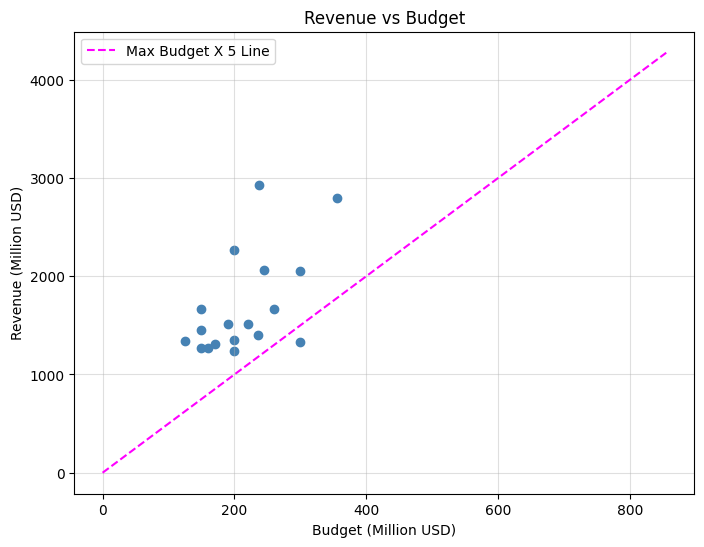

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(plot_df["budget_musd"], plot_df["revenue_musd"], c="steelblue")

# Reference line
max_budget = plot_df["budget_musd"].max()
roi_x = range(0, int(max_budget)+500)
roi_y = [x * 5 for x in roi_x]
plt.plot(roi_x, roi_y, "--", color="magenta", label="Max Budget X 5 Line")

plt.xlabel("Budget (Million USD)")
plt.ylabel("Revenue (Million USD)")
plt.title("Revenue vs Budget")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


In [72]:
under_5x = plot_df[plot_df["revenue_musd"] < 5 * plot_df["budget_musd"]]

under_5x[["title", "budget_musd", "revenue_musd", "profit_musd", "roi"]]

,title,budget_musd,revenue_musd,profit_musd,roi
9,Star Wars: The Last Jedi,300.0,1332.69883,1032.69883,4.442329


Movies above the red line achieved exceptionally high ROI. Most titles fall on a positive trend. This means that movies with higher budgets generally earn more revenue, but only a few come close to achieving very high returns relative to what they cost. This shows that while larger productions tend to make more money overall, they are not always the most financially efficient.

There was only one movie (**Star Wars: The Last Jedi**) whose revenue failed to exceed 5 times its budget and it is among the ones with the highest budgets in our data.

#### **ROI Distribution by Genre**

Now for the genre analysis. Let us lookat the mean Return on Ivestment by genre.

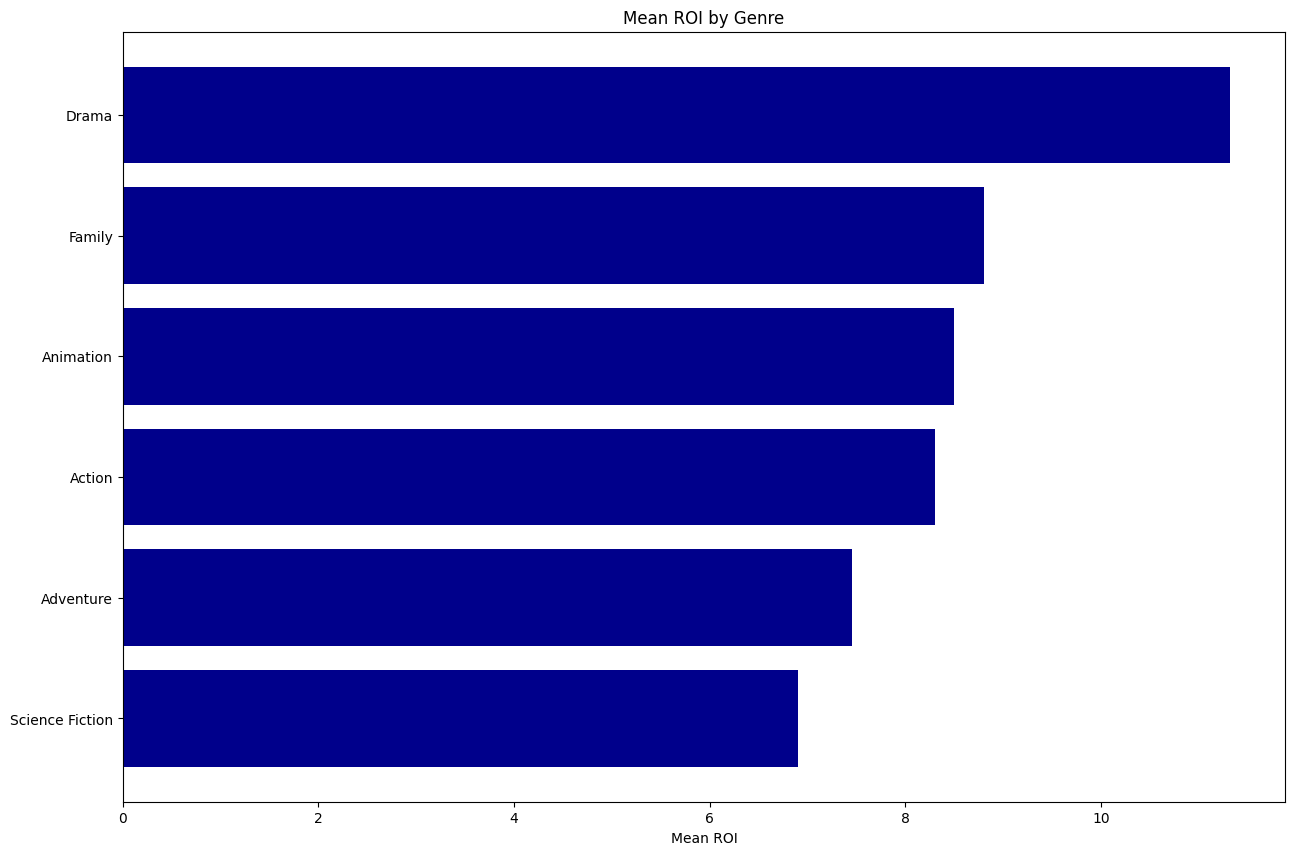

In [75]:
# compute mean ROI per primary genre
roi_mean = (
    plot_df.dropna(subset=["roi"])
            .assign(primary_genre=lambda df: df["genres"].str.split("|").str[0])
            .groupby("primary_genre")["roi"]
            .mean()
            .sort_values()
)

plt.figure(figsize=(15,10))
plt.barh(roi_mean.index, roi_mean.values, color="darkblue")
plt.xlabel("Mean ROI")
plt.title("Mean ROI by Genre")
plt.show()

Drama and Family movies tend to give the best return for the money spent, while genres like Animation and Action still perform well but with slightly lower efficiency. Adventure and Science Fiction show the smallest returns compared to their production costs. Overall, some of the less effects-heavy genres appear to stretch their budgets a bit further.

#### **Popularity vs. Rating**

One would want to check if the movies' rating really depends on their popularity. So that is what we are going to do now.

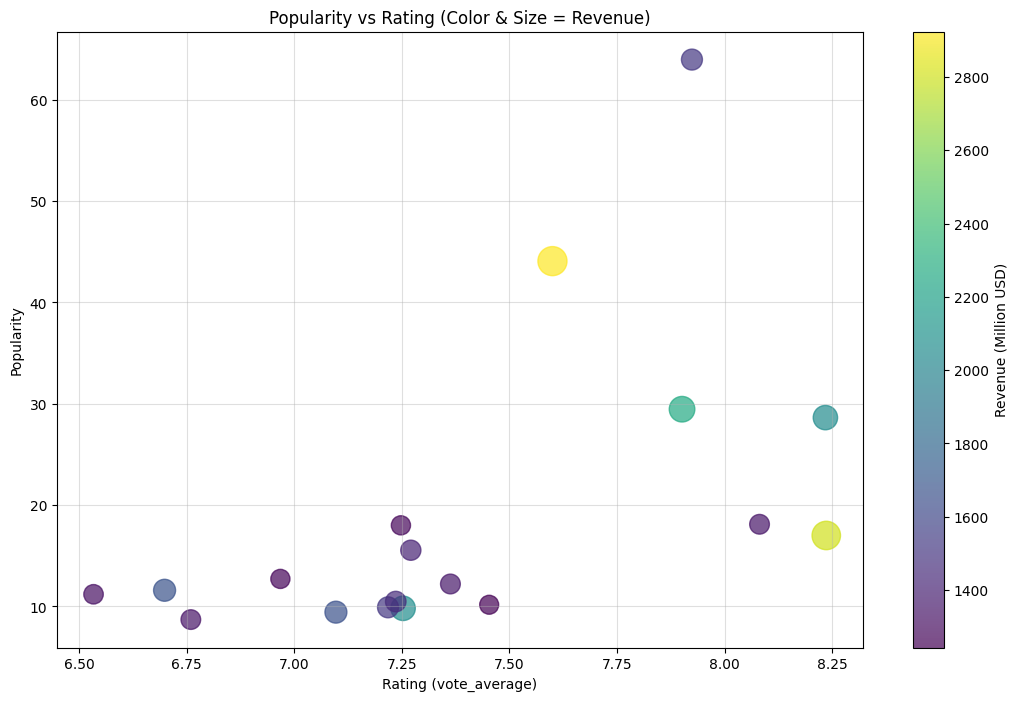

In [66]:
plt.figure(figsize=(13,8))

sizes = plot_df["revenue_musd"] * 0.15
colors = plot_df["revenue_musd"]    

scatter = plt.scatter(
    plot_df["vote_average"],
    plot_df["popularity"],
    s=sizes,
    c=colors,
    alpha=0.7,
    cmap="viridis"     
)

plt.xlabel("Rating (vote_average)")
plt.ylabel("Popularity")
plt.title("Popularity vs Rating (Color & Size = Revenue)")
plt.grid(alpha=0.4)

cbar = plt.colorbar(scatter)
cbar.set_label("Revenue (Million USD)")

plt.show()

Movies with higher ratings don’t always have the highest popularity, but the ones that are both well-rated and widely talked about stand out clearly. The larger bubbles show that the biggest earners tend to sit in this upper area, meaning revenue often follows a mix of strong audience interest withmost especially good ratings.

#### **Trends in Box Office Performance**

Does Revenue generated by a movie really depend on its release date? We are going to see the annual released movies trend of revenue generated.

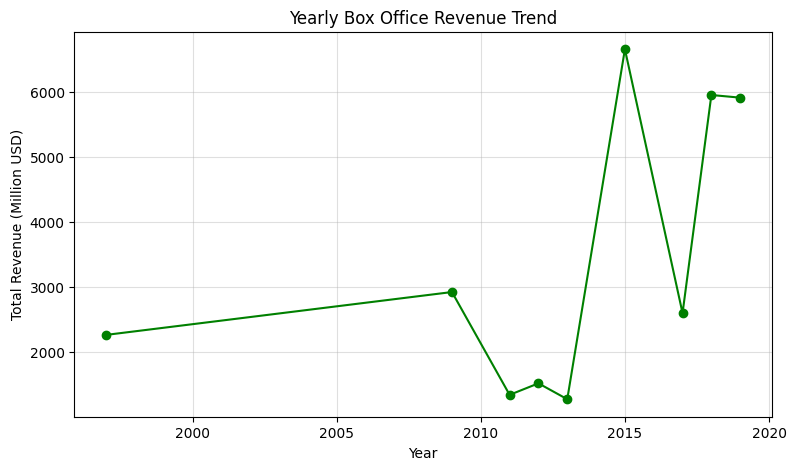

In [74]:
plot_df["release_date"] = pd.to_datetime(plot_df["release_date"], errors="coerce")

plot_df["year"] = plot_df["release_date"].dt.year

yearly = plot_df.groupby("year")["revenue_musd"].sum()

plt.figure(figsize=(9,5))
plt.plot(yearly.index, yearly.values, "-o", color="green")
plt.xlabel("Year")
plt.ylabel("Total Revenue (Million USD)")
plt.title("Yearly Box Office Revenue Trend")
plt.grid(alpha=0.4)
plt.show()


Total revenue changes a lot from year to year in this dataset. There’s a clear dip around 2010–2012, followed by a sharp jump in the mid-2010s when some very high-earning movies were released. The last few years stay relatively high, suggesting stronger titles in the later period of the dataset.

#### **Franchise vs. Standalone Success**

We saw earlier the comparison of movies that don't belong to any particular collection and those that do. The stand-alone movies performed relatively better. Let us visualize this for a more clear view and understanding.

<Figure size 700x600 with 0 Axes>

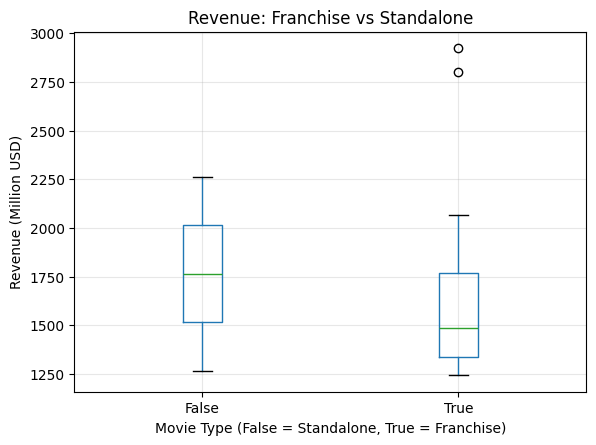

In [77]:
plot_df["is_franchise"] = plot_df["belongs_to_collection"].notna()
plt.figure(figsize=(7,6))
plot_df.boxplot(column="revenue_musd", by="is_franchise")
plt.title("Revenue: Franchise vs Standalone")
plt.suptitle("")
plt.xlabel("Movie Type (False = Standalone, True = Franchise)")
plt.ylabel("Revenue (Million USD)")
plt.grid(alpha=0.3)
plt.show()


Both standalone and franchise movies show a wide mix of revenues, but their typical values are fairly close. Standalone films sit a little higher in the middle range, while a few franchise titles rise far above the rest. This suggests that standalone typically does better, with franchises occasionally producing very big hits.

#### **Top Movies**

Let us also visualiza the most profitable movies for a clear comparison. This will give value to what we saw earlier. These are the top 10 movies:

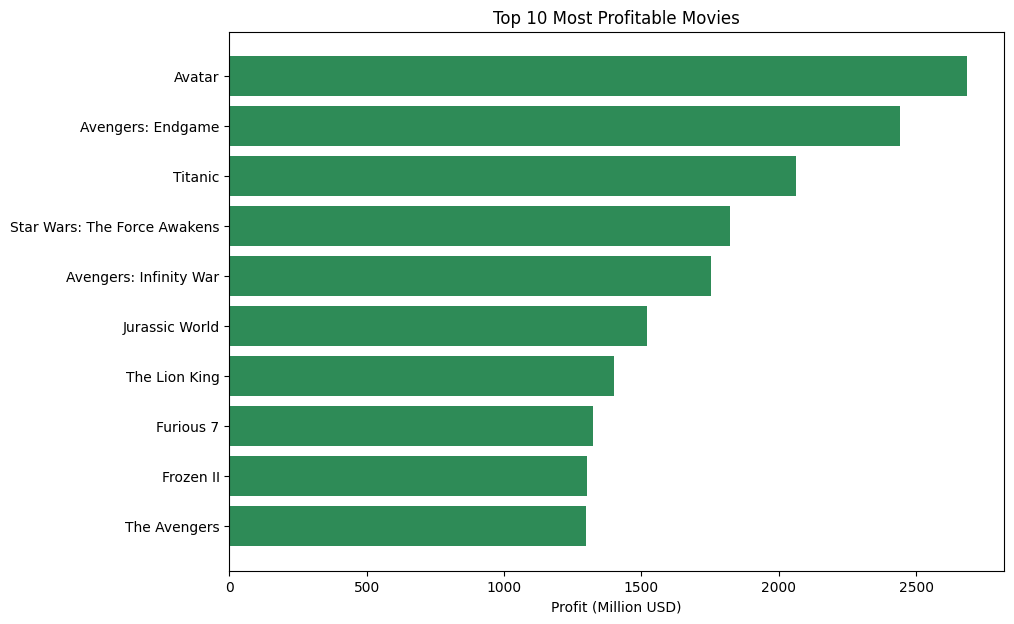

In [78]:
top_profit = plot_df.sort_values("profit_musd", ascending=False).head(10)

plt.figure(figsize=(10,7))
plt.barh(top_profit["title"], top_profit["profit_musd"], color="seagreen")
plt.xlabel("Profit (Million USD)")
plt.title("Top 10 Most Profitable Movies")
plt.gca().invert_yaxis()
plt.show()

Like we saw earlier, Avatar is the first. It is followed somewhat closely by Avengers: Endgame.

#### **Top Directors**
Now for the directors. A top 10 directors visual to add to the aggregation table

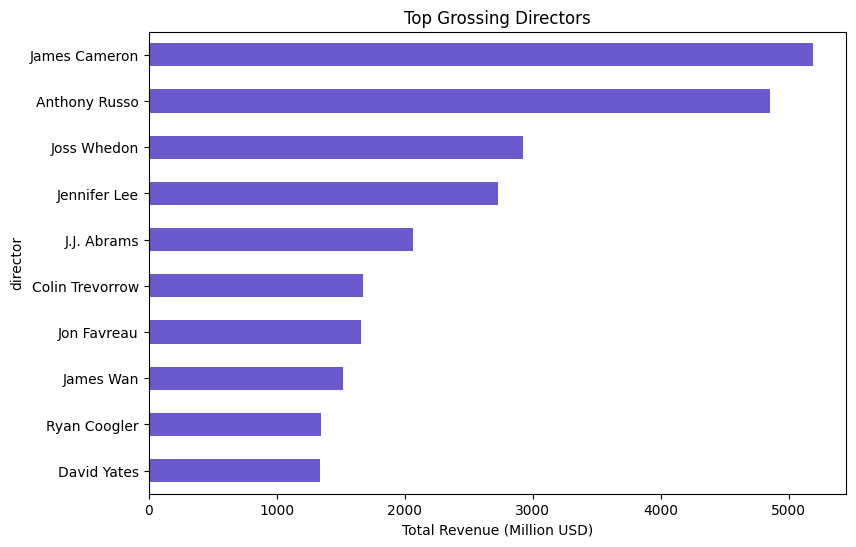

In [87]:
director_df = plot_df.groupby("director")["revenue_musd"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,6))
director_df.head(10).plot(kind="barh", color="slateblue")
plt.xlabel("Total Revenue (Million USD)")
plt.title("Top Grossing Directors")
plt.gca().invert_yaxis()
plt.show()

This doesn't clearly capture the story we got from the table. We know that the first two Directors have 2 entries each in our data. This means that even though they have the most grossing revenue, it could be because we are adding up the revenue across thrir movies. So let us see the mean now.

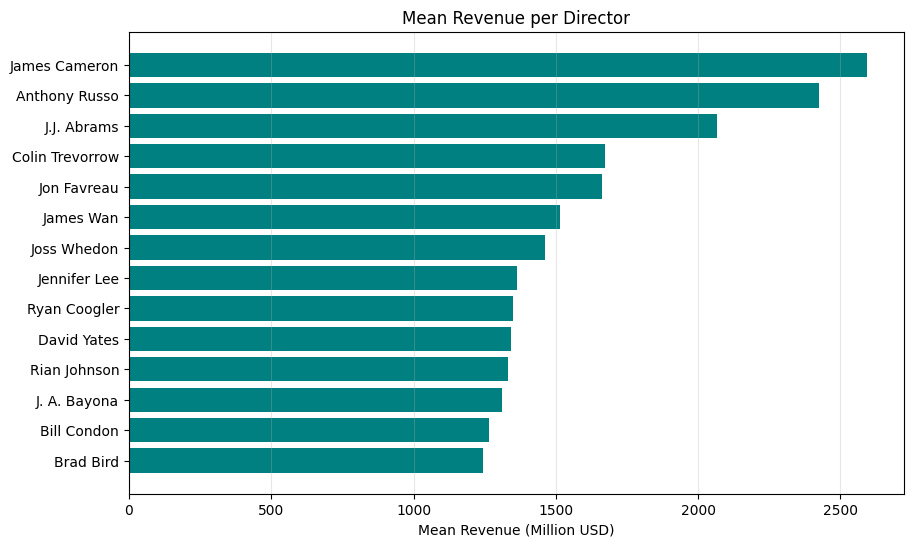

In [86]:
director_mean_rev = (
    plot_df
    .groupby("director")["revenue_musd"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
bars = plt.barh(director_mean_rev.index, director_mean_rev.values, color="teal")
plt.xlabel("Mean Revenue (Million USD)")
plt.title("Mean Revenue per Director")
plt.grid(axis='x', alpha=0.3)

plt.show()

We see a slight shift now with J.J Abrams who came from the fifth to the third place as well as some others too. Joss Whedon moved back 4 places from the third to the seventh. But overall, the first two directors keep there places.